# Modelo para la Predicción de Adiciones en Tiempo y Valor

Preguntas de investigación del artículo:
1. ¿Qué tan precisas pueden ser predicciones de las desviacione en tiempo y costo en proyectos de infraestructura?
2. ¿Que tan relevantes pueden ser los diferentes grupos de variables del proyecto: características del proyecto y el proceso de contratación, indicadores de desempeño de la entidad, indicadores de desempeño del contratista, y variablex exogenas?
3. Caules son las principales características del proyecto que determinan las desviaciones
4. Caules son los principales indicadores de la entidad para determinar proyecto que determinan las desviaciones
5. Caules son los principales indicadores del contratista para determinar proyecto que determinan las desviaciones
6. Caules son las principales variables exogenas para determinar proyecto que determinan las desviaciones



In [137]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [138]:
# Import data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#from transformData import dataCleaning
pd.set_option('display.max_columns', None)

In [139]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Carga de Datos

In [140]:
df = pd.read_csv('contratosSECOPCleaned.csv')   # Load the data

<ipython-input-140-540de7bec0b0>:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('contratosSECOPCleaned.csv')   # Load the data


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30993 entries, 0 to 30992
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   uid                        30993 non-null  object 
 1   buyerName                  30993 non-null  object 
 2   buyerId                    30993 non-null  object 
 3   buyerDepartment            30993 non-null  object 
 4   buyerLevel                 30993 non-null  object 
 5   contractMethodCountryLaw   30993 non-null  object 
 6   contractType               30993 non-null  object 
 7   contractDescription        30993 non-null  object 
 8   contractTotalValue         30993 non-null  float64
 9   contractDateSigned         30993 non-null  object 
 10  contractStartDate          30993 non-null  object 
 11  contractEndDate            30993 non-null  object 
 12  urlTender                  30993 non-null  object 
 13  supplierId                 30992 non-null  obj

# Metodología

1. Limpieza de datos
2. Datos extremos
3. Ingeniería de variables (año electoral, etc.)
4. Indicadores de la entidad
5. Indicadores de los contratistas
6. Variables exogenas (Terridata, otras fuentes)
7. Entrenar modelos: seleccionar el conjunto del top 5 con el mejor desempeño
8. Calibrar el top5 de los modelos
9. Definir n escenarios con diferentes subconjuntos de variables para verificar el aporte de estos nuevos subconjuntos
10. Comparar el top5 de los modelos con los diferentes escenarios
11. Realizar un análisis e interpretación de las variables más importantes (Verificar el enfoque de gallego)

# Procesamiento de datos

## Lista de tareas de limpieza
- Eliminar contratos con desviación en costo superior al 50% (No se permite por ley)
- Transformación logaritmica a la variable valor del contrato
- Quitar contratos de menos de un mes de duración (No tiene sentido para contratos de obra)
- Quitar valores extremos en las desviaciones en tiempo (Arriba del percentil 99%)
- Quitar contratos cuyo award growth se encuentra por del -100% o arriba del 20%
- Quitar valores extremos en el project intensity (Arriba del percentil 99%)
- Quitar contratos firmado en 2024 (no representativos en la muestra)
- Quitar contratos que registren una duración superior a los 5 años

## Cost Overruns

In [142]:
# Count cost overruns
(
    df['haveCostDeviation']
    .value_counts()
    .reset_index(name='n')
    .assign(p = lambda x: x['n']/x['n'].sum())
)

,haveCostDeviation,n,p
0,0,22801,0.735682
1,1,8192,0.264318


In [143]:
# Count time overruns
(
    df['haveTimeDeviation']
    .value_counts()
    .reset_index(name='n')
    .assign(p = lambda x: x['n']/x['n'].sum())
)

,haveTimeDeviation,n,p
0,0,21952,0.708289
1,1,9041,0.291711


In [144]:
df['costDeviationPerc'].describe()

,costDeviationPerc
count,30993.000000
mean,0.087319
std,1.573019
min,-0.575244
25%,0.000000
50%,0.000000
75%,0.036188
max,249.728140


In [145]:
np.sum(df['costDeviationPerc'] > 0.5)

278

In [146]:
np.sum(df['costDeviationPerc'] < 0.0)

51

In [147]:
# Filter contracts with less of 50% of cost deviation
df = df.loc[(df['costDeviationPerc'] >= 0.0) & (df['costDeviationPerc'] <= 0.5)]

In [148]:
(df['contractValue']/1e6).describe()

,contractValue
count,30664.000000
mean,1276.901713
std,7008.564109
min,33.992696
25%,125.473179
50%,261.950582
75%,782.433349
max,595218.801803


### Schedule Deviation

In [149]:
df['contractDurationDays'].describe()

,contractDurationDays
count,30664.000000
mean,106.775698
std,120.364646
min,0.000000
25%,60.000000
50%,90.000000
75%,120.000000
max,9450.000000


In [150]:
sum(df['contractDurationDays'] < 30)

1464

In [151]:
# Filter contracts with almost 30 days of duration
df = df.loc[df['contractDurationDays'] >= 30]

In [152]:

df['timeDeviationPerc'].describe()

,timeDeviationPerc
count,29200.000000
mean,0.215888
std,0.606107
min,0.000000
25%,0.000000
50%,0.000000
75%,0.208333
max,24.500000


In [153]:
df['timeDeviationPerc'].quantile(0.99)

2.488999999999982

In [154]:
df = df.loc[df['timeDeviationPerc'] < df['timeDeviationPerc'].quantile(0.99)]

In [155]:
df.shape

(28908, 48)

In [156]:
df['databaseSource'].value_counts()

,count
databaseSource,
SECOPI,27250
SECOPII,1658


### Award Growth

In [157]:
df['awardGrowth'].describe()

,awardGrowth
count,28908.000000
mean,0.363946
std,16.886156
min,-0.999028
25%,-0.003000
50%,-0.000144
75%,0.000000
max,999.000000


In [158]:
np.sum(df['awardGrowth'] > 0.2) + np.sum(df['awardGrowth'] < -1)

151

In [159]:
df = df.loc[(df['awardGrowth'] > -1) & (df['awardGrowth'] < 0.2)]

In [160]:
df.shape

(28757, 48)

### Project intensity

In [161]:
df['projectIntensityMw'].describe()

,projectIntensityMw
count,28757.000000
mean,9.615334
std,20.362223
min,0.038767
25%,2.516542
50%,4.541577
75%,9.483782
max,1386.660253


In [162]:
df['projectIntensityMw'].quantile(0.99)

79.61325722077153

In [163]:
np.sum(df['projectIntensityMw'] > df['projectIntensityMw'].quantile(0.99))

288

In [164]:
df = df.loc[df['projectIntensityMw'] < df['projectIntensityMw'].quantile(0.99)]

In [165]:
df.shape

(28469, 48)

### Year Signed

In [166]:
(
    df.groupby(['contractYearSigned'])
    .size()
    .reset_index(name='n')
    .assign(p = lambda x: x['n']/x['n'].sum())
)

,contractYearSigned,n,p
0,2014,3243,0.113913
1,2015,4340,0.152447
2,2016,1889,0.066353
3,2017,3386,0.118936
4,2018,3534,0.124135
5,2019,4104,0.144157
6,2020,1461,0.051319
7,2021,2480,0.087112
8,2022,2168,0.076153
9,2023,1790,0.062875


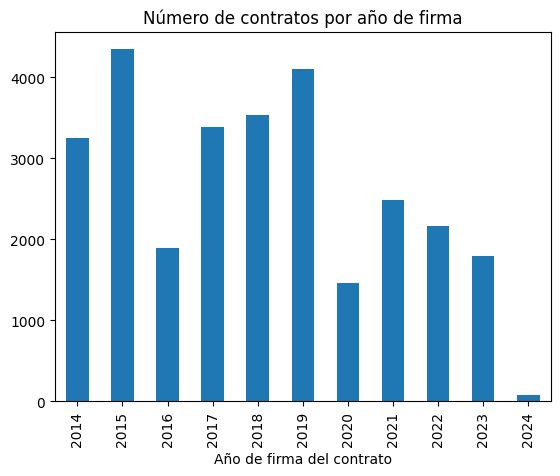

In [167]:
# Número de contratos por año de firma
df.groupby('contractYearSigned').size().plot.bar()
plt.title('Número de contratos por año de firma')
plt.xlabel('Año de firma del contrato')
plt.show()

In [168]:
#df = df.loc[df['contractYearSigned'] < 2024]

In [169]:
df.shape

(28469, 48)

### Contract Duration

In [170]:
sum(df['contractDurationDays'] > 360*5)

19

In [171]:
df = df.loc[df['contractDurationDays'] < 360*5]

In [172]:
df.shape

(28449, 48)

## Exploratory Data Analysis

In [173]:
df.columns

Index(['uid', 'buyerName', 'buyerId', 'buyerDepartment', 'buyerLevel',
       'contractMethodCountryLaw', 'contractType', 'contractDescription',
       'contractTotalValue', 'contractDateSigned', 'contractStartDate',
       'contractEndDate', 'urlTender', 'supplierId', 'isBusinessGroup',
       'isSME', 'isPostConflictContract', 'buyerLocation', 'supplierName',
       'tenderStatus', 'contractYearSigned', 'tenderValue', 'contractValue',
       'supplierDepartment', 'awardId', 'contractAditionalValue',
       'databaseSource', 'contractMonthSigned', 'contractMonthStart',
       'contractMonthEnd', 'tenderValueMw', 'contractValueMw',
       'contractAditionalValueMw', 'contractTotalValueMw',
       'contractDurationDays', 'contractAditionalDuration',
       'contractTotalDuration', 'haveCostDeviation', 'haveTimeDeviation',
       'haveTimeAndCostDeviation', 'projectIntensity', 'projectIntensityMw',
       'awardGrowth', 'costDeviationPerc', 'timeDeviationPerc', 'buyerRegion',
       'con

In [174]:
numericColumns = ['tenderValueMw',
                  'contractValueMw',
                  'contractDurationDays',
                  'projectIntensityMw',
                  'awardGrowth']


In [175]:
categoricalColumns = [
                      #'buyerDepartment',
                      'buyerLevel',
                      'contractMethodType',
                      'buyerRegion',
                      #'supplierDepartment',
                      'supplierRegion',
                      'isBusinessGroup',
                      'isSME',
                      'isPostConflictContract',
                      'databaseSource'
                      ]

In [176]:
dateColumns = ['contractMonthSigned',
               'contractMonthStart',
               #'contractYearSigned'
               ]

In [177]:
deviationColumns = ['haveCostDeviation', 'haveTimeDeviation', 'haveTimeAndCostDeviation','costDeviationPerc', 'timeDeviationPerc']

In [178]:
set(dateColumns) - set(df.columns)

set()

In [179]:
df[numericColumns].describe()

,tenderValueMw,contractValueMw,contractDurationDays,projectIntensityMw,awardGrowth
count,28449.000000,28449.000000,28449.000000,28449.000000,28449.000000
mean,1416.526331,1207.372350,107.393125,8.290871,-0.015407
std,7832.513773,2691.867288,78.034574,10.506128,0.080770
min,27.827170,27.765372,30.000000,0.091694,-0.999028
25%,168.395965,166.630591,60.000000,2.501287,-0.003000
50%,338.849074,333.619957,90.000000,4.496301,-0.000148
75%,1035.684401,1000.639059,120.000000,9.295032,0.000000
max,782386.544058,54087.380115,1740.000000,79.549507,0.199334


In [180]:
print('-'*50)
print('Summary of categorical columns')
for i in categoricalColumns:
    print('-'*50)
    print(df[i].value_counts())


--------------------------------------------------
Summary of categorical columns
--------------------------------------------------
buyerLevel
TERRITORIAL               25558
NATIONAL                   2824
AUTONOMOUS CORPORATION       64
NOT DEFINED                   3
Name: count, dtype: int64
--------------------------------------------------
contractMethodType
SIMPLIFIED        13051
OPEN              10967
SPECIAL REGIME     3276
CLOSED              656
LIMITED             355
OTHER               144
Name: count, dtype: int64
--------------------------------------------------
buyerRegion
ANDINA       18105
PACIFICA      3592
ORINOQUIA     3370
CARIBE        2174
AMAZONIA      1199
OTHER            9
Name: count, dtype: int64
--------------------------------------------------
supplierRegion
ANDINA       17317
ORINOQUIA     3489
PACIFICA      3486
CARIBE        2346
AMAZONIA      1178
OTHER          633
Name: count, dtype: int64
--------------------------------------------------
is

In [181]:
print('-'*50)
print('Summary of date columns')
for i in dateColumns:
    print('-'*50)
    print(df.groupby(i).size())

--------------------------------------------------
Summary of date columns
--------------------------------------------------
contractMonthSigned
1      951
2     1261
3     1528
4     1735
5     1976
6     2251
7     2432
8     2547
9     2967
10    3431
11    3446
12    3924
dtype: int64
--------------------------------------------------
contractMonthStart
1     1407
2     1397
3     1462
4     1699
5     1948
6     2147
7     2391
8     2586
9     2922
10    3386
11    3720
12    3384
dtype: int64


In [182]:
df[['contractValueMw','contractDurationDays','projectIntensityMw','awardGrowth','haveCostDeviation']].groupby(['haveCostDeviation']).describe().T.round(1)

haveCostDeviation                 0        1
contractValueMw      count  21138.0   7311.0
                     mean    1076.5   1585.7
                     std     2470.3   3218.9
                     min       38.9     27.8
                     25%      158.4    204.1
                     50%      287.5    487.0
                     75%      855.7   1437.5
                     max    48380.5  54087.4
contractDurationDays count  21138.0   7311.0
                     mean     101.7    123.9
                     std       72.7     89.7
                     min       30.0     30.0
                     25%       60.0     60.0
                     50%       90.0     90.0
                     75%      120.0    150.0
                     max     1350.0   1740.0
projectIntensityMw   count  21138.0   7311.0
                     mean       7.8      9.7
                     std        9.9     11.9
                     min        0.1      0.1
                     25%        2.4      2.7
                     50%        4.3      5.2
                     75%        8.7     11.3
                     max       79.5     78.8
awardGrowth          count  21138.0   7311.0
                     mean      -0.0     -0.0
                     std        0.1      0.1
                     min       -1.0     -1.0
                     25%       -0.0     -0.0
                     50%       -0.0     -0.0
                     75%        0.0     -0.0
                     max        0.2      0.2

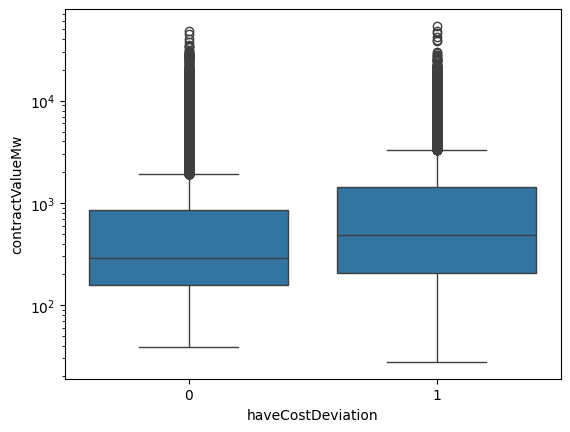

In [183]:
sns.boxplot(data=df, x='haveCostDeviation', y='contractValueMw')
plt.yscale('log')
plt.show()

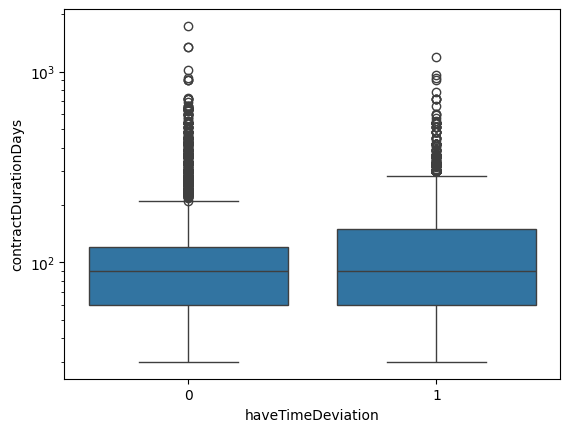

In [184]:
sns.boxplot(data=df, x='haveTimeDeviation', y='contractDurationDays')
plt.yscale('log')
plt.show()

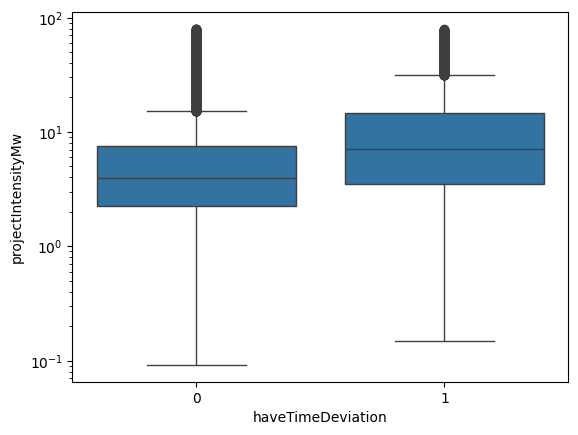

In [185]:
sns.boxplot(data=df, x='haveTimeDeviation', y='projectIntensityMw')
plt.yscale('log')
plt.show()

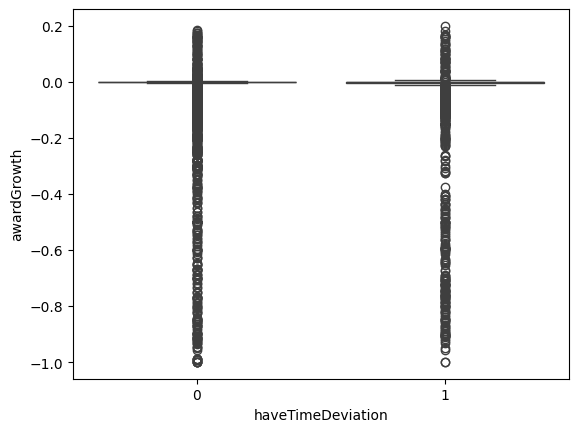

In [186]:
sns.boxplot(data=df, x='haveTimeDeviation', y='awardGrowth')
#plt.yscale('log')
plt.show()

## Ingeniería de Variables

- Incluir si el proveedor es  pyme
- Incluir el proveedor es un grupo
- Incluir el departamento del proveedor es igual al departamento de la entidad
-

### Año preelectoral

In [187]:
anno_electoral_presidente = [i for i in np.arange(2010,2024,4)]
anno_electoral_presidente

[2010, 2014, 2018, 2022]

In [188]:
df['electoralYear'] = df['contractYearSigned'].apply(lambda x: 1 if x in anno_electoral_presidente else 0)
df['electoralYear']

,electoralYear
0,0
1,0
2,0
3,1
4,0
...,...
30987,1
30988,0
30989,1
30990,1


In [189]:
df[df['electoralYear'] == 1].groupby('contractYearSigned').size()

,0
contractYearSigned,
2014,3241
2018,3531
2022,2166


In [190]:
addVars = ['electoralYear']

# Modelos ML: Con Características del Contratos

In [191]:
# Data Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

# Model Selection & Validation
from sklearn.model_selection import train_test_split, cross_val_score

# Cross validation and hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold


# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Pipeline & Imbalanced Data Handling
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Model Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

# Natural Language Processing
import nltk

In [192]:
metricasModelos = dict()

## Definición de las variables

In [193]:
# Define features and target variable
target_variable = 'haveCostDeviation'

# Separate features and target
X = df[numericColumns + categoricalColumns + dateColumns]
y = df[target_variable]

## División train/test

In [194]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Pipeline de Preprocesamiento

In [195]:
# Define preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

date_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Transform date columns if needed
])

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numericColumns),
        ('cat', categorical_transformer, categoricalColumns),
        ('date', date_transformer, dateColumns)
    ]
)

## Funciones para Entrenar, Evaluar y Analizar las Variables

In [196]:
def trainModel(clf, X_train, y_train, X_test, y_test, Smote=True, sampling_strategy='auto'):
  if Smote:
    # Define the pipeline with SMOTE
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=42)),  # Apply SMOTE to balance the dataset
        ('classifier', clf)
    ])
  else:
    # Define the model
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])


  # Train the model
  model.fit(X_train, y_train)

  return model

In [197]:
def evaluateModel(model, X_test, y_test):
  from yellowbrick.classifier import ROCAUC
  # Predictions
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

  # Generate confusion matrix
  cm = confusion_matrix(y_test, y_pred)

  # Define class labels
  class_labels = ["No", "Yes"]

  # Create a DataFrame for better visualization
  cm_df = pd.DataFrame(cm,
                      index=[f"Actual: {label}" for label in class_labels],
                      columns=[f"Predicted: {label}" for label in class_labels])
  print("-"*60)
  print("Confusion Matrix:")
  print(cm_df)
  print("-"*60)

  # Classification Report
  print("Classification Report:\n", classification_report(y_test, y_pred))
  print("-"*60)

  # Compute performance metrics
  roc_auc = roc_auc_score(y_test, y_prob)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  # Store results in a dictionary
  metrics = {
    'AUC ROC': round(roc_auc, 4),
    'Accuracy': round(accuracy, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-Score': round(f1, 4)
  }

  # Crear la figura con un tamaño más pequeño
  plt.figure(figsize=(5, 4))  # Ajusta el tamaño (ancho x alto)
  # Create a ROCAUC visualizer using the trained model
  ROCAUCviz = ROCAUC(model.named_steps['classifier'])

  # Fit the visualizer to the transformed training data
  ROCAUCviz.fit(model.named_steps['preprocessor'].transform(X_train), y_train)

  # Score the model using the transformed test data
  ROCAUCviz.score(model.named_steps['preprocessor'].transform(X_test), y_test)

  # Show the ROC Curve
  ROCAUCviz.show()

  return metrics

In [198]:
def varsImportance(model, X_test, y_test, n=20, absolute=False):
  from yellowbrick.model_selection import FeatureImportances
  # Create a FeatureImportances visualizer using the trained pipeline
  viz = FeatureImportances(model.named_steps['classifier'], labels=[
      *numericColumns,
      *model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categoricalColumns),
      *model.named_steps['preprocessor'].transformers_[2][1].named_steps['onehot'].get_feature_names_out(dateColumns)],
                           topn=n,
                           absolute=absolute)

  # Fit to the training data
  viz.fit(model.named_steps['preprocessor'].transform(X_train), y_train)

  # Show the plot
  viz.show()

## Logistic Regression

### Ajustar hiperparámetros

In [199]:
from scipy.stats import uniform

In [200]:
#lrHpoPipeModel = Pipeline(steps=[
#        ('preprocessor', preprocessor),
#        ('smote', SMOTE(sampling_strategy='auto', random_state=42)),  # Apply SMOTE to balance the dataset
#        ('classifier', LogisticRegression(random_state=42))
#    ])

# 5. Parameter Grid/Distributions (same as before)
#param_distributions = {
#    'classifier__C': uniform(loc=0, scale=100),
#    'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
#    'classifier__solver': ['liblinear', 'saga', 'newton-cg', 'lbfgs', 'sag'],
#    'classifier__l1_ratio': uniform(loc=0, scale=1)
#}

# 6. GridSearchCV/RandomizedSearchCV (using the full pipeline)
#cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


#random_search = RandomizedSearchCV(lrHpoPipeModel, param_distributions, n_iter=50, cv=cv, scoring='f1', verbose=1, n_jobs=-1, random_state=42)
#random_search.fit(X_train, y_train)


In [201]:
#best_params = random_search.best_params_

# Access specific best parameters
#best_C = best_params['classifier__C']
#best_penalty = best_params['classifier__penalty']
#best_solver = best_params['classifier__solver']
#best_l1_ratio = best_params.get('classifier__l1_ratio', None)  # Some solvers don't use l1_ratio

# Print extracted parameters
#print(f"Best C: {best_C}")
#print(f"Best Solver: {best_solver}")
##print(f"Best Penalty: {best_penalty}")
#    print(f"Best L1 Ratio: {best_l1_ratio}")
#if best_l1_ratio is not None:


### Entrenar el modelo

In [202]:
# Keep only the parameters relevant to the selected solver
#valid_params = {k.replace("classifier__", ""): v for k, v in best_params.items()}  # Remove "classifier__" prefix

# Remove `l1_ratio` if the solver doesn't support ElasticNet (only 'saga' supports it)
#if valid_params['solver'] not in ['saga']:
#    valid_params.pop('l1_ratio', None)  # Remove l1_ratio if not supported


In [203]:
# Crear el clasificador
lrClf = LogisticRegression(random_state=42, max_iter=1000)
lrClfSmote = LogisticRegression(random_state=42, max_iter=1000)

In [204]:
lrModel = trainModel(lrClf, X_train, y_train, X_test, y_test, Smote=False)
lrModelSmote = trainModel(lrClfSmote, X_train, y_train, X_test, y_test, Smote=True)

### Evaluar el modelo

------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            4143              85
Actual: Yes           1354             108
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.98      0.85      4228
           1       0.56      0.07      0.13      1462

    accuracy                           0.75      5690
   macro avg       0.66      0.53      0.49      5690
weighted avg       0.70      0.75      0.67      5690

------------------------------------------------------------


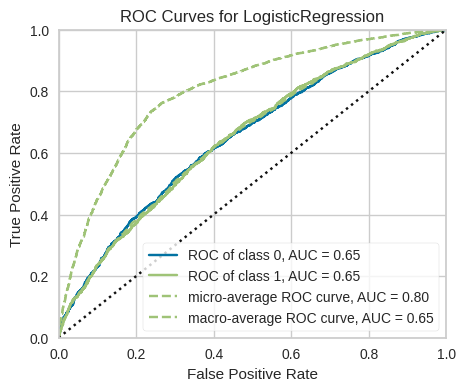

In [205]:
lrModelMetrics = evaluateModel(lrModel, X_test, y_test)

------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            2514            1714
Actual: Yes            552             910
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.59      0.69      4228
           1       0.35      0.62      0.45      1462

    accuracy                           0.60      5690
   macro avg       0.58      0.61      0.57      5690
weighted avg       0.70      0.60      0.63      5690

------------------------------------------------------------


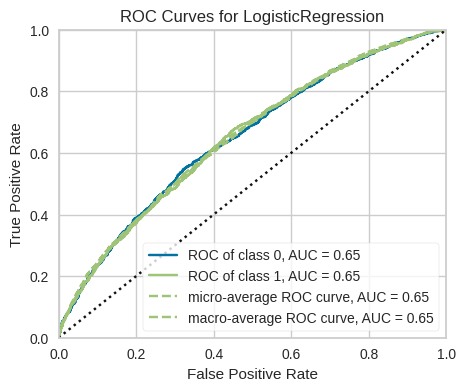

In [206]:
lrModelSmoteMetrics = evaluateModel(lrModelSmote, X_test, y_test)

In [207]:
metricasModelos['Logistic Regression'] = lrModelMetrics
metricasModelos['Logistic Regression (SMOTE)'] = lrModelSmoteMetrics

### Analizar las variables

/usr/local/lib/python3.11/dist-packages/yellowbrick/model_selection/importances.py:194: YellowbrickWarning: detected multi-dimensional feature importances but stack=False, using mean to aggregate them.
  warnings.warn(


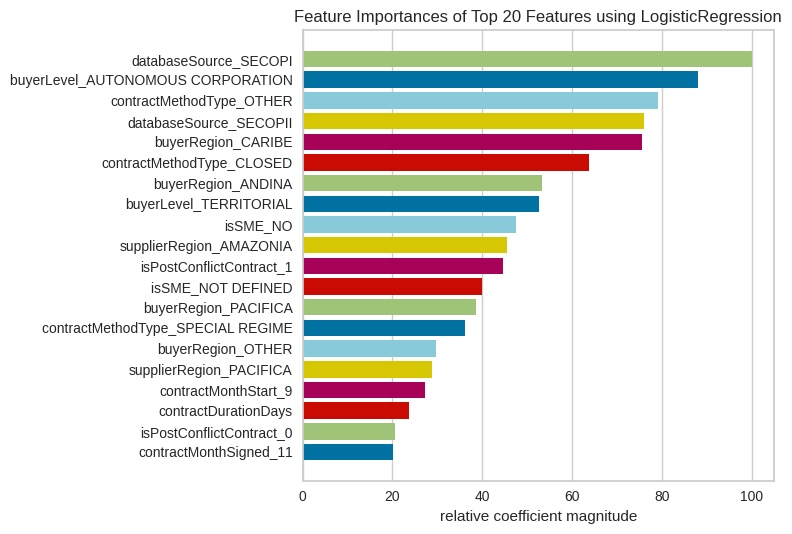

In [208]:
varsImportance(model=lrModelSmote, X_test=X_test, y_test=y_test, n=20, absolute=True)

## Random Forest

### Ajustar hiperparámetros

In [209]:
#from imblearn.pipeline import Pipeline as ImbPipeline


In [210]:
#!pip install optuna

In [211]:
# import optuna
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_auc_score
# from sklearn.model_selection import cross_val_score

# # Define the objective function
# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'max_depth': trial.suggest_int('max_depth', 10, 50),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
#         'random_state': 42
#     }
#     model = ImbPipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('smote', SMOTE(sampling_strategy='auto', random_state=42)),  # Balance dataset
#     ('classifier', RandomForestClassifier(**params))])

#     #model = RandomForestClassifier(**params)
#     score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
#     return score

# # Run the optimization
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# # Best parameters
# print("Best Parameters:", study.best_params)

In [212]:
# rf_pipeline = ImbPipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('smote', SMOTE(sampling_strategy='auto', random_state=42)),  # Balance dataset
#     ('classifier', RandomForestClassifier(random_state=42))
# ])

# # Define the hyperparameter space
# param_distributions = {
#     'classifier__n_estimators': np.arange(50, 500, 50),  # Number of trees
#     'classifier__max_depth': [None, 10, 20, 30, 40, 50],  # Depth of trees
#     'classifier__min_samples_split': [2, 5, 10],  # Min samples required to split
#     'classifier__min_samples_leaf': [1, 2, 4],  # Min samples in leaf node
#     'classifier__max_features': ['auto', 'sqrt', 'log2'],  # Number of features per split
#     'classifier__bootstrap': [True, False]  # Use bootstrap sampling
# }

# # Define cross-validation strategy
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Perform RandomizedSearchCV
# random_search = RandomizedSearchCV(rf_pipeline, param_distributions,
#                                    n_iter=50, cv=cv, scoring='f1',
#                                    verbose=2, n_jobs=-1, random_state=42)

# # Fit RandomizedSearchCV
# random_search.fit(X_train, y_train)

In [213]:
# # Extract the best hyperparameters
# best_params = random_search.best_params_
# print("Best Hyperparameters:", best_params)

### Entrenar el modelo

In [214]:
rfClf = RandomForestClassifier(n_estimators=200, random_state=42)
rfClfSmote = RandomForestClassifier(n_estimators=200, random_state=42)

In [215]:
rfModel = trainModel(rfClf, X_train, y_train, X_test, y_test, Smote=False)

In [216]:
rfModel

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tenderValueMw',
                                                   'contractValueMw',
                                                   'contractDurationDays',
                                                   'projectIntensityMw',
                                                   'awardGrowth']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['buyerLevel',
                                                   'contractMethodType',
                                                   'buyerRegion',
                                                   'supplierRegion',
                                                   'isBusinessGroup', 'isSME',
                                                   'isPostConflictContract',
                                                   'databaseSource']),
                                                 ('date',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['contractMonthSigned',
                                                   'contractMonthStart'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [217]:
rfModelSmote = trainModel(rfClfSmote, X_train, y_train, X_test, y_test, Smote=True, sampling_strategy=0.8)

In [218]:
rfModelSmote

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tenderValueMw',
                                                   'contractValueMw',
                                                   'contractDurationDays',
                                                   'projectIntensityMw',
                                                   'awardGrowth']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['buyerLevel',
                                                   'contractMethodType',
                                                   'buyerRegion',
                                                   'supplierRegion',
                                                   'isBusinessGroup', 'isSME',
                                                   'isPostConflictContract',
                                                   'databaseSource']),
                                                 ('date',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['contractMonthSigned',
                                                   'contractMonthStart'])])),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.8)),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

### Evaluar el modelo

Modelo de Random Forest sin SMOTE
------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            3953             275
Actual: Yes           1198             264
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.93      0.84      4228
           1       0.49      0.18      0.26      1462

    accuracy                           0.74      5690
   macro avg       0.63      0.56      0.55      5690
weighted avg       0.70      0.74      0.69      5690

------------------------------------------------------------


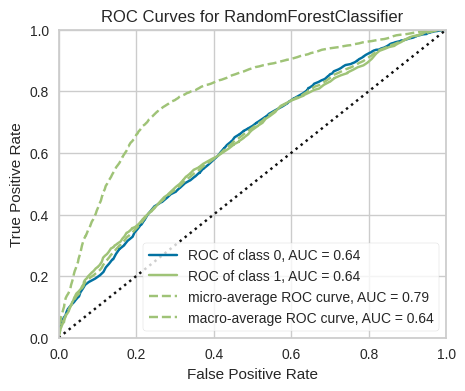

In [219]:
print("Modelo de Random Forest sin SMOTE")
rfModelMetrics = evaluateModel(rfModel, X_test, y_test)

Modelo de Random Forest con SMOTE
------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            3520             708
Actual: Yes           1002             460
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80      4228
           1       0.39      0.31      0.35      1462

    accuracy                           0.70      5690
   macro avg       0.59      0.57      0.58      5690
weighted avg       0.68      0.70      0.69      5690

------------------------------------------------------------


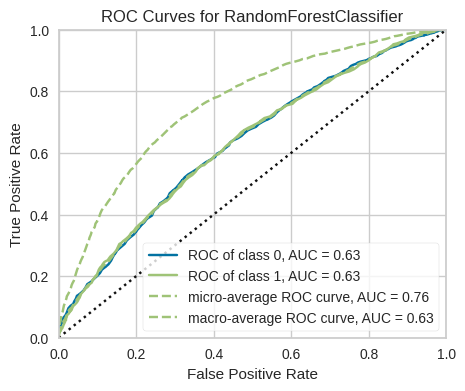

In [220]:
print("Modelo de Random Forest con SMOTE")
rfModelSmoteMetrics = evaluateModel(rfModelSmote, X_test, y_test)

In [221]:
metricasModelos['Random Forest'] = rfModelMetrics
metricasModelos['Random Forest (SMOTE)'] = rfModelSmoteMetrics

### Analizar las variables

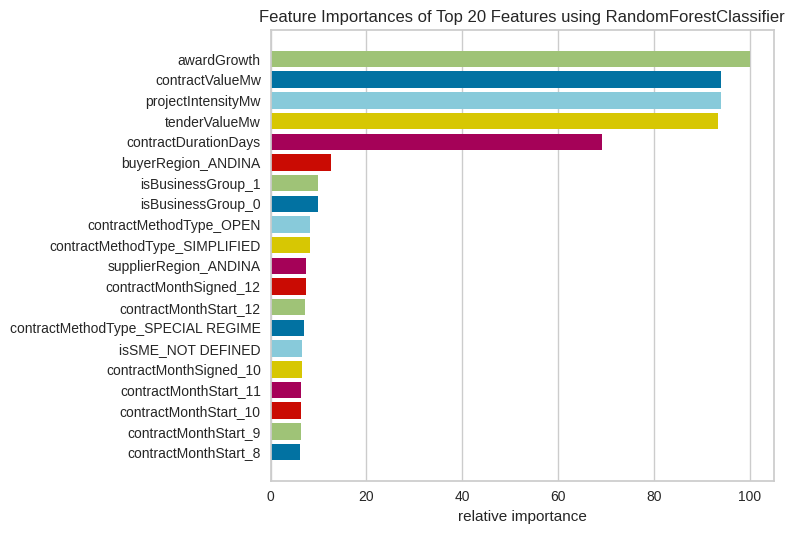

In [222]:
varsImportance(model=rfModelSmote, X_test=X_test, y_test=y_test, n=20, absolute=True)

## Gradient Boosting Machine

### Ajustar hiperparámetros

### Entrenar el modelo

In [223]:
gbmClf = GradientBoostingClassifier(n_estimators=300, random_state=42)
gbmClfSmote = GradientBoostingClassifier(n_estimators=300, random_state=42)

In [224]:
gbmModel = trainModel(gbmClf, X_train, y_train, X_test, y_test, Smote=False)

In [225]:
gbmModelSmote = trainModel(gbmClfSmote, X_train, y_train, X_test, y_test, Smote=True, sampling_strategy='auto')

### Evaluar el modelo

Modelo de Gradient Boosting Machine sin SMOTE
------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            4141              87
Actual: Yes           1339             123
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.98      0.85      4228
           1       0.59      0.08      0.15      1462

    accuracy                           0.75      5690
   macro avg       0.67      0.53      0.50      5690
weighted avg       0.71      0.75      0.67      5690

------------------------------------------------------------


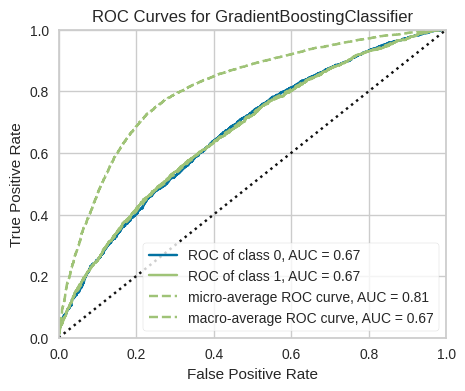

In [226]:
print("Modelo de Gradient Boosting Machine sin SMOTE")
gbmModelMetrics = evaluateModel(gbmModel, X_test, y_test)

Modelo de Gradient Boosting Machine con SMOTE
------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            3272             956
Actual: Yes            864             598
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78      4228
           1       0.38      0.41      0.40      1462

    accuracy                           0.68      5690
   macro avg       0.59      0.59      0.59      5690
weighted avg       0.69      0.68      0.68      5690

------------------------------------------------------------


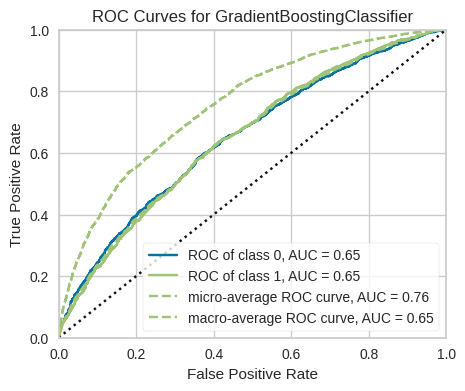

In [227]:
print("Modelo de Gradient Boosting Machine con SMOTE")
gbmModelSmoteMetrics = evaluateModel(gbmModelSmote, X_test, y_test)

In [228]:
metricasModelos['Gradient Boosting Machine'] = gbmModelMetrics
metricasModelos['Gradient Boosting Machine (SMOTE)'] = gbmModelSmoteMetrics

### Analizar las variables

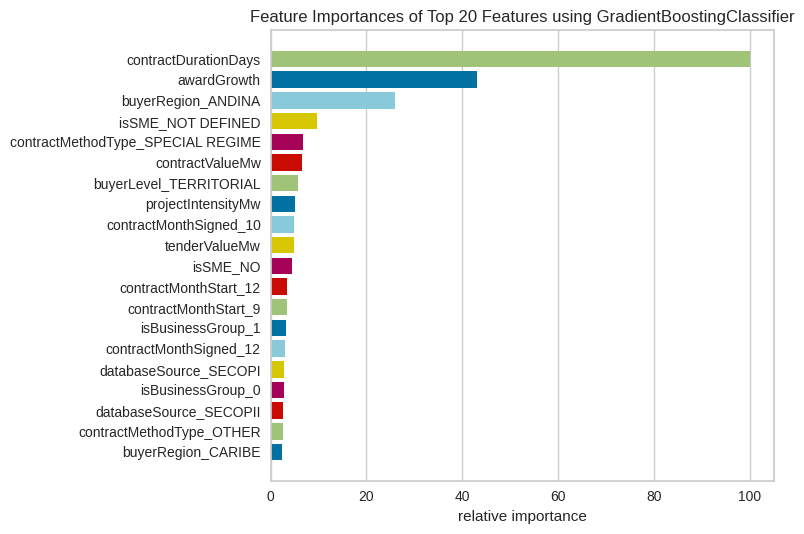

In [229]:
varsImportance(model=gbmModelSmote, X_test=X_test, y_test=y_test, n=20, absolute=True)

## Extreme Gradiente Boosting

### Ajustar hiperparámetros

### Entrenar el modelo

In [230]:
xgbClf = XGBClassifier(n_estimators=300, random_state=42)
xgbClfSmote = XGBClassifier(n_estimators=300, random_state=42)

In [231]:
xgbModel = trainModel(xgbClf, X_train, y_train, X_test, y_test, Smote=False)

In [232]:
xgbModelSmote = trainModel(xgbClfSmote, X_train, y_train, X_test, y_test, Smote=True, sampling_strategy='auto')

### Evaluar el modelo

Modelo de Extreme Gradiente Boosting sin SMOTE
------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            3909             319
Actual: Yes           1178             284
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.92      0.84      4228
           1       0.47      0.19      0.28      1462

    accuracy                           0.74      5690
   macro avg       0.62      0.56      0.56      5690
weighted avg       0.69      0.74      0.69      5690

------------------------------------------------------------


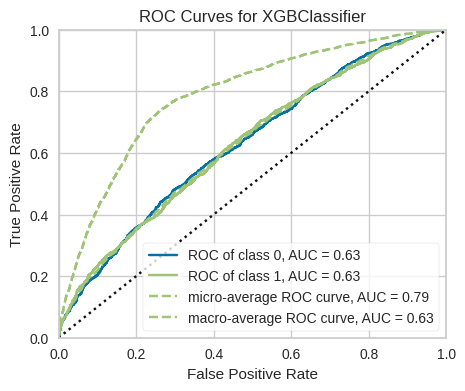

In [233]:
print("Modelo de Extreme Gradiente Boosting sin SMOTE")
xgbModelMetrics = evaluateModel(xgbModel, X_test, y_test)

Modelo de Extreme Gradiente Boosting con SMOTE
------------------------------------------------------------
Confusion Matrix:
             Predicted: No  Predicted: Yes
Actual: No            3342             886
Actual: Yes            942             520
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.79      4228
           1       0.37      0.36      0.36      1462

    accuracy                           0.68      5690
   macro avg       0.57      0.57      0.57      5690
weighted avg       0.67      0.68      0.68      5690

------------------------------------------------------------


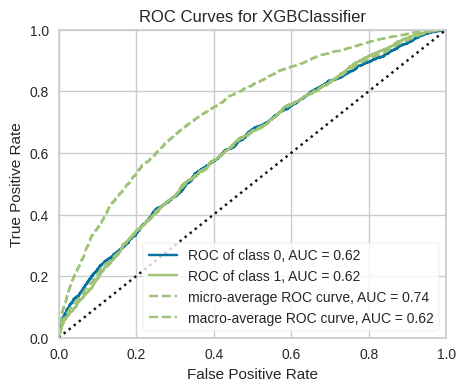

In [234]:
print("Modelo de Extreme Gradiente Boosting con SMOTE")
xgbModelSmoteMetrics = evaluateModel(xgbModelSmote, X_test, y_test)

In [235]:
metricasModelos['Extreme Gradiente Boosting'] = xgbModelMetrics
metricasModelos['Extreme Gradiente Boosting (SMOTE)'] = xgbModelSmoteMetrics

### Analizar las variables

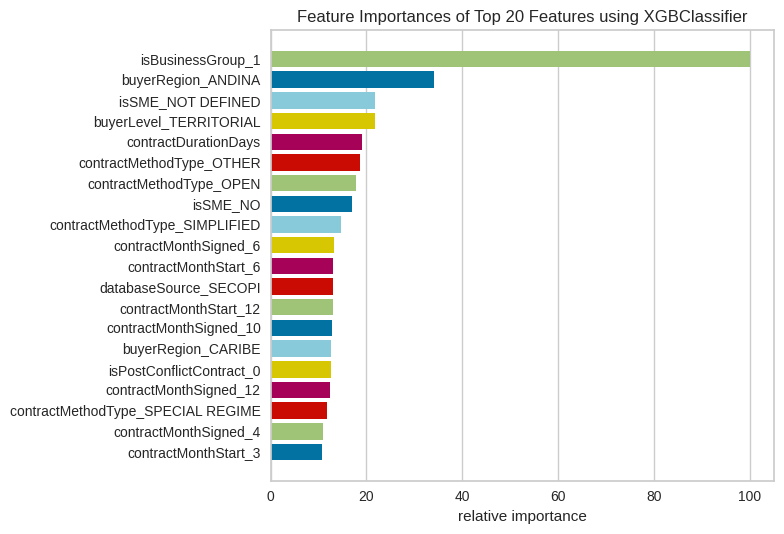

In [236]:
varsImportance(model=xgbModelSmote, X_test=X_test, y_test=y_test, n=20, absolute=True)

## Comparación de métricas

In [237]:
pd.DataFrame(metricasModelos).T.sort_values(by='AUC ROC', ascending=False)

,AUC ROC,Accuracy,Precision,Recall,F1-Score
Gradient Boosting Machine,0.6687,0.7494,0.5857,0.0841,0.1471
Gradient Boosting Machine (SMOTE),0.6509,0.6801,0.3848,0.4090,0.3966
Logistic Regression,0.6501,0.7471,0.5596,0.0739,0.1305
Logistic Regression (SMOTE),0.6485,0.6018,0.3468,0.6224,0.4454
Random Forest,0.6351,0.7411,0.4898,0.1806,0.2639
Random Forest (SMOTE),0.6315,0.6995,0.3938,0.3146,0.3498
Extreme Gradiente Boosting,0.6301,0.7369,0.4710,0.1943,0.2751
Extreme Gradiente Boosting (SMOTE),0.6243,0.6787,0.3698,0.3557,0.3626


<Figure size 800x400 with 0 Axes>

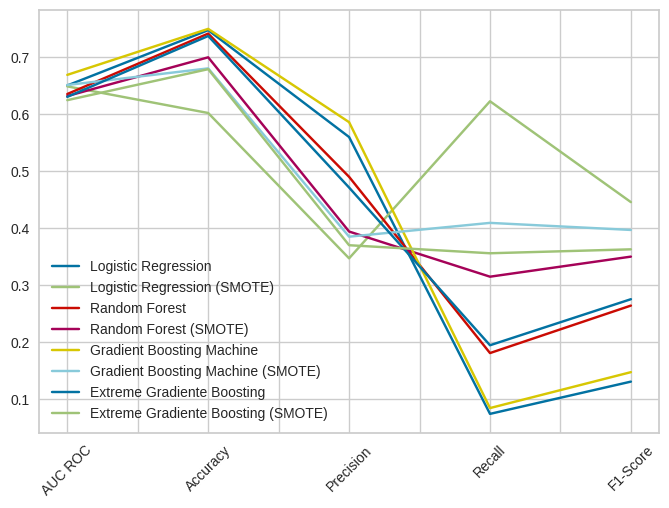

In [238]:
plt.figure(figsize=(8,4))
pd.DataFrame(metricasModelos).plot()
plt.xticks(rotation=45)
plt.show()

## Indicadores Historicos de la Entidad Pública

**Penalidades:**
- Si la entidad o el contratista tienen penalidades antes de la firma del contrato
- Numero de pendalidades de la entidad antes de la firma del contrato
- Tiempo transcurrido antes de la última penalidad

**Experiencia:**
- Número de contratos de obra de la entidad antes de la firma del contrato
- Número de contratos de obra de la entidad en los últimos 5 $(n)$ años antes de la firma del contrato
- Porcentaje de contratos de obra exitosos o con desviaciones antes de la firma del contrato
- Porcentaje de contratos con desviaciones en tiempo antes de la firma del contrato
- Porcentaje de contratos con desviacioens en costo antes de la firma del contrato
- Número de contratos activos
- Número de licitaciones (en obra o cualquier tipo)
- Promedio de oferentes por licitación (en obra o cualquier tipo)
- Porcentaje de contratos abiertos o cerrados (en obra o cualquier tipo)
- Concentración de la contratación (HHI, IC4k, ID Simsomp)
- Valor promedio de los contratos
- Promedio de contratos por año

Estrategia:
1. Construir un Datawarehouse con una serie de bases de datos relacionales (entidad, multas, contratista, municipio) en las cuales se guarden los indicadores y luego se hace un join



In [ ]:
import random

In [ ]:
random_dates = [pd.Timestamp('2014-01-01') + pd.to_timedelta(random.randint(0, 3652), unit='D') for _ in range(50)]
random_dates

[Timestamp('2023-08-11 00:00:00'),
 Timestamp('2018-12-17 00:00:00'),
 Timestamp('2018-08-02 00:00:00'),
 Timestamp('2022-08-27 00:00:00'),
 Timestamp('2020-04-16 00:00:00'),
 Timestamp('2018-05-05 00:00:00'),
 Timestamp('2014-03-31 00:00:00'),
 Timestamp('2019-08-28 00:00:00'),
 Timestamp('2017-12-29 00:00:00'),
 Timestamp('2022-03-05 00:00:00'),
 Timestamp('2016-08-19 00:00:00'),
 Timestamp('2015-11-08 00:00:00'),
 Timestamp('2017-11-02 00:00:00'),
 Timestamp('2020-09-16 00:00:00'),
 Timestamp('2015-12-18 00:00:00'),
 Timestamp('2023-12-15 00:00:00'),
 Timestamp('2017-03-30 00:00:00'),
 Timestamp('2017-11-19 00:00:00'),
 Timestamp('2022-02-24 00:00:00'),
 Timestamp('2022-04-08 00:00:00'),
 Timestamp('2017-11-05 00:00:00'),
 Timestamp('2014-03-26 00:00:00'),
 Timestamp('2021-01-06 00:00:00'),
 Timestamp('2023-11-11 00:00:00'),
 Timestamp('2015-08-26 00:00:00'),
 Timestamp('2019-09-07 00:00:00'),
 Timestamp('2017-12-15 00:00:00'),
 Timestamp('2018-10-08 00:00:00'),
 Timestamp('2023-12-

In [ ]:
df = pd.DataFrame()
# create random sample of date bwteen 2014-01-01 and 2023-12-31
random_dates = [pd.Timestamp('2014-01-01') + pd.to_timedelta(random.randint(0, 3652), unit='D') for _ in range(20000)]
df['date'] = pd.DataFrame({'random_dates': random_dates})
#df['date'] = pd.to_datetime(np.random.randint(1388534400, 1704067200, 20000), unit='s')
# create a set of 100 buyers
df['buyer'] = np.random.choice(['buyer' + str(i+1) for i in range(50)], 20000)
# create a set of 400 suppliner
df['supplier'] = np.random.choice(['supplier' + str(i+1) for i in range(400)], 20000)
# create a sample variable with random values 1 and 0
df['deviation'] = np.array([1 if i < 0.30 else 0 for i in np.random.rand(20000)])
# create a columns with a contract value using a tailed distribution witn mean 1e6 and std 1e6
df['contractValue'] = np.random.lognormal(mean=13, sigma=1, size=20000)
# create a variable with mean cumulative by group and ordered by date
df['avgDeviation'] = df.sort_values(by='date').groupby('buyer')['deviation'].transform(lambda x: x.shift(1).rolling(window=len(x), min_periods=1).mean())
df['avgcontractValue'] = df.sort_values(by='date').groupby('buyer')['contractValue'].transform(lambda x: x.shift(1).rolling(window=len(x), min_periods=1).mean())
df

,date,buyer,supplier,deviation,contractValue,avgDeviation,avgcontractValue
0,2023-02-26,buyer40,supplier87,0,178480.405499,0.303621,760285.649040
1,2017-12-22,buyer7,supplier220,0,108352.283275,0.292994,692834.176106
2,2016-10-09,buyer2,supplier315,0,97744.715589,0.324561,838885.083503
3,2018-10-18,buyer9,supplier330,0,206304.021977,0.285714,722095.988039
4,2019-12-14,buyer10,supplier253,0,51548.917203,0.336170,829097.982064
...,...,...,...,...,...,...,...
19995,2015-03-06,buyer29,supplier20,0,151330.393230,0.340000,485316.302572
19996,2022-04-18,buyer8,supplier297,0,87183.896815,0.326923,771535.573515
19997,2015-01-23,buyer27,supplier98,0,590073.824413,0.195652,606891.758045
19998,2022-11-23,buyer38,supplier311,0,319828.733860,0.283988,696794.009754


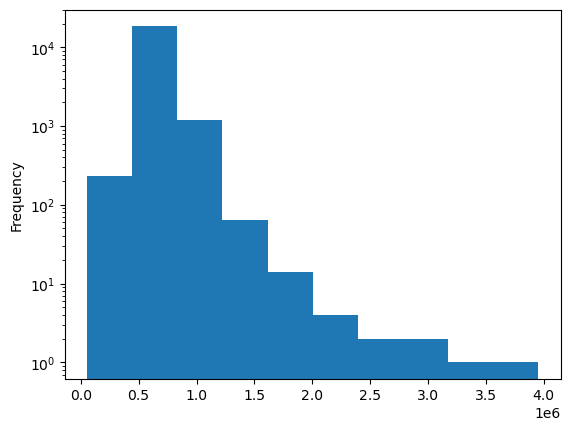

In [ ]:
df['avgcontractValue'].plot.hist()
plt.yscale('log')
plt.show()

In [ ]:
sum(datos['buyerName'].value_counts() < 10)

1017

<Axes: xlabel='date'>

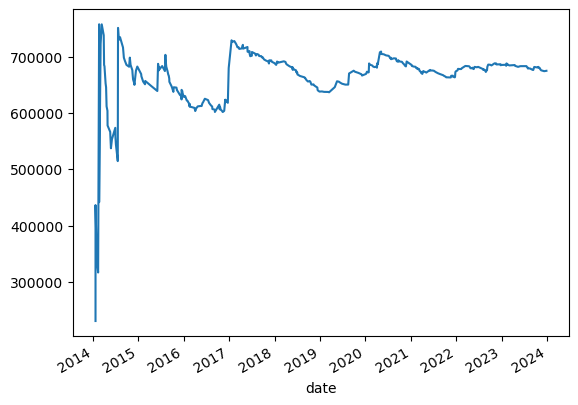

In [ ]:
df[df['buyer'] == 'buyer1'].sort_values(by='date').set_index('date')['avgcontractValue'].plot()

In [ ]:
df.describe()

,date,deviation,contractValue
count,20000,20000.000000,2.000000e+04
mean,2018-12-28 08:36:44.640000,0.703350,7.252229e+05
min,2014-01-01 00:00:00,0.000000,9.386323e+03
25%,2016-06-18 18:00:00,0.000000,2.271287e+05
50%,2018-12-28 00:00:00,1.000000,4.439835e+05
75%,2021-06-29 00:00:00,1.000000,8.726119e+05
max,2024-01-01 00:00:00,1.000000,1.878825e+07
std,NaN,0.456792,9.027691e+05


In [ ]:
df[df['buyer'] == 'buyer1'].to_excel('data/df_buyer1.xlsx', index=False)

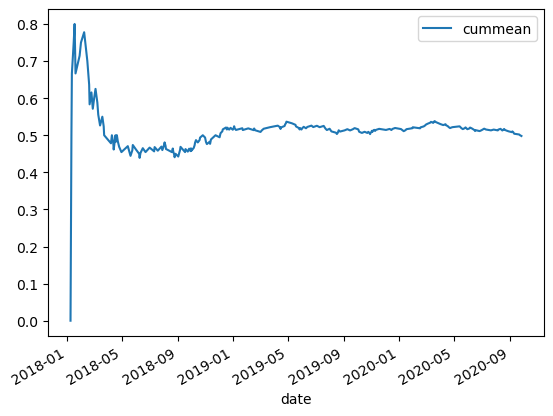

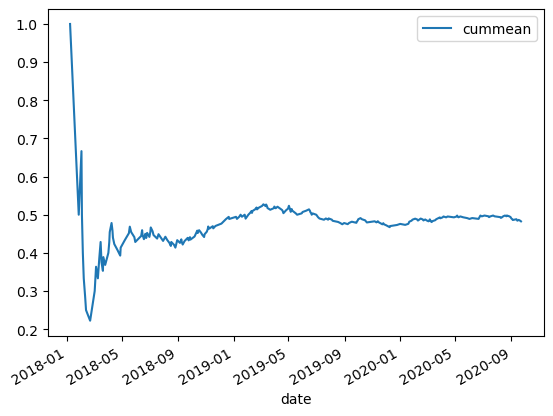

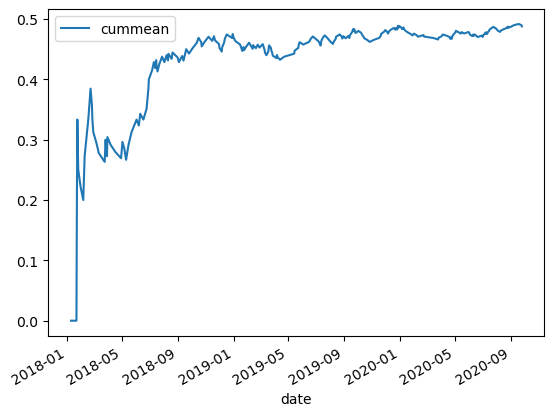

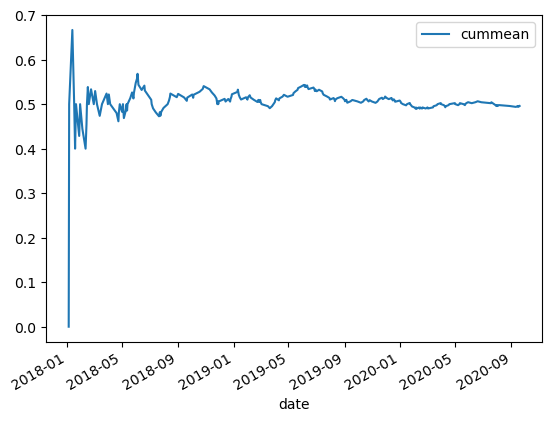

In [ ]:
# plot cummean by group
df.groupby('group').plot(x='date', y='cummean')
plt.show()

In [ ]:
x = np.random.rand(10)
y = np.array([0 if i < 0.5 else 1 for i in x])

In [ ]:
y

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0])

In [ ]:
y.cumsum()/[i+1 for i in range(10)]

array([0.        , 0.        , 0.        , 0.25      , 0.4       ,
       0.33333333, 0.28571429, 0.375     , 0.33333333, 0.3       ])

### Penalidades en los Contratos

In [ ]:
datos.columns

Index(['uid', 'buyerName', 'buyerDepartment', 'buyerLevel',
       'contractMethodCountryLaw', 'contractType', 'direct_contracting_cause',
       'contractCategory', 'contractDescription', 'tenderValue',
       'contractValue', 'contractAditionalValue', 'contractTotalValue',
       'contractYearSigned', 'contractDateSigned', 'contractStartDate',
       'contractDuration', 'contractEndDate', 'awardId', 'urlTender',
       'buyerId', 'supplierId', 'supplierLocation', 'buyerLocation',
       'supplierName', 'tenderStatus', 'contractMonthSigned',
       'contractStartMonth', 'contractEndMonth', 'tenderValueMw',
       'contractValueMw', 'contractAditionalValueMw', 'contractTotalValueMw',
       'contractAditionalDuration', 'contractTotalDuration',
       'haveCostDeviation', 'haveTimeDeviation', 'haveTimeAndCostDeviation',
       'projectIntensity', 'projectIntensityMw', 'awardGrowth',
       'costDeviationPerc', 'timeDeviationPerc', 'buyerGovernmentLevel',
       'buyerRegion', 'contractM

In [ ]:
from etl.extractData import get_path, get_query, parse_to_list, querySecop

In [ ]:
SECOPI_PUNISHMENT_API = '4n4q-k399'

In [ ]:
datos[datos['buyerId'] == 'No Definido']

,uid,buyerName,buyerDepartment,buyerLevel,contractMethodCountryLaw,contractType,direct_contracting_cause,contractCategory,contractDescription,tenderValue,contractValue,contractAditionalValue,contractTotalValue,contractYearSigned,contractDateSigned,contractStartDate,contractDuration,contractEndDate,awardId,urlTender,buyerId,supplierId,supplierLocation,buyerLocation,supplierName,tenderStatus,contractMonthSigned,contractStartMonth,contractEndMonth,tenderValueMw,contractValueMw,contractAditionalValueMw,contractTotalValueMw,contractAditionalDuration,contractTotalDuration,haveCostDeviation,haveTimeDeviation,haveTimeAndCostDeviation,projectIntensity,projectIntensityMw,awardGrowth,costDeviationPerc,timeDeviationPerc,buyerGovernmentLevel,buyerRegion,contractMethod,electoralYear
0,15-1-147652-4032692,CUNDINAMARCA - ALCALDiA MUNICIPIO DE UBAQUE,CUNDINAMARCA,Type 6,LICITACION PUBLICA,OBRA,NO DEFINIDO,"TERRENOS, EDIFICIOS, ESTRUCTURAS Y ViAS",CONTRATAR MEDIANTE EL SISTEMA DE PRECIOS UNITA...,7.004600e+08,7.004600e+08,0.000000e+00,7.004600e+08,2015,2015-10-26,2015-11-10,120,2016-03-10,4032692,{'url': 'https://www.contratos.gov.co/consulta...,No Definido,900902330-1,CUNDINAMARCA,UBAQUE,UNION TEMPORAL FISTEGA,LIQUIDADO,10,11,3,1087.079978,1087.079978,0.000000,1087.079978,0,120,0,0,0,5.837167e+06,9.059000,0.000000,0.000000,0.000000,Local Government,ANDINA,Open,0
25,22-11-13077202-12251808,CUNDINAMARCA - ALCALDiA MUNICIPIO DE LA PEÑA,CUNDINAMARCA,Type 6,SELECCION ABREVIADA DE MENOR CUANTIA (LEY 1150...,OBRA,LA CONTRATACION DE MENOR CUANTIA (LITERAL B),HERRAMIENTAS Y MAQUINARIA GENERAL,CONSTRUCCION OBRAS DE MANEJO HIDRAULICO EN LA ...,2.760001e+08,2.759742e+08,0.000000e+00,2.759742e+08,2022,2022-06-06,2022-07-05,120,2022-11-05,12251808,{'url': 'https://www.contratos.gov.co/consulta...,No Definido,79595822,CUNDINAMARCA,LA PEÑA,ADENAWER MAHECHA MAHECHA,LIQUIDADO,6,7,11,276.000061,275.974164,0.000000,275.974164,0,120,0,0,0,2.299785e+06,2.299785,-0.000094,0.000000,0.000000,Local Government,ANDINA,Simplified,1
34,15-1-132644-3597235,GUAINiA - GOBERNACIoN,GUAINiA,Deparment decentralized,LICITACION PUBLICA,OBRA,NO DEFINIDO,"SERVICIOS DE EDIFICACIoN, CONSTRUCCIoN DE INST...",CONSTRUCCION DE LOS PUESTOS DE SALUD EL PAUJIL...,6.012448e+09,6.010510e+09,1.082602e+09,7.093112e+09,2015,2015-03-19,2015-04-13,240,2016-08-13,3597235,{'url': 'https://www.contratos.gov.co/consulta...,No Definido,900831094,GUAINiA,INiRIDA,CONSORCIO CHORROBOCON 2015,LIQUIDADO,3,4,8,9331.027819,9328.020947,1680.145657,11008.166604,259,499,1,1,1,2.504379e+07,38.866754,-0.000322,0.180118,1.079167,Department,OTRA,Open,0
45,19-11-9106280-8411938,ANTIOQUIA - ALCALDiA MUNICIPIO DE TURBO,ANTIOQUIA,Type 6,SELECCION ABREVIADA DE MENOR CUANTIA (LEY 1150...,OBRA,NO DEFINIDO,"SERVICIOS BASADOS EN INGENIERiA, INVESTIGACIoN...",ADECUACION Y MANTENIMIENTO DE LA INFRAESTRUCTU...,3.200000e+08,3.199943e+08,0.000000e+00,3.199943e+08,2019,2019-03-29,2019-03-29,30,2019-04-28,8411938,{'url': 'https://www.contratos.gov.co/consulta...,No Definido,900740660,ANTIOQUIA,TURBO,CONSTRUCCIONES OMICRONS S.A.S,LIQUIDADO,3,3,4,386.419294,386.412387,0.000000,386.412387,0,30,0,0,0,1.066648e+07,12.880413,-0.000018,0.000000,0.000000,Local Government,ANDINA,Simplified,0
46,15-11-4236216-3984456,META - ALCALDiA MUNICIPIO DE PUERTO LLERAS,META,Type 6,SELECCION ABREVIADA DE MENOR CUANTIA (LEY 1150...,OBRA,NO DEFINIDO,"TERRENOS, EDIFICIOS, ESTRUCTURAS Y ViAS",MANTENIMIENTO DE VIAS RURALES EN EL MUNICIPIO ...,1.091200e+08,1.090361e+08,0.000000e+00,1.090361e+08,2015,2015-10-08,2015-10-19,60,2015-12-19,3984456,{'url': 'https://www.contratos.gov.co/consulta...,No Definido,94368948-9,META,PUERTO LLERAS,CARLOS ARTURO ARBOLEDA GARZON,LIQUIDADO,10,10,12,169.348955,169.218676,0.000000,169.218676,0,60,0,0,0,1.817268e+06,2.820311,-0.000769,0.000000,0.000000,Local Government,ORINOQUIA,Simplified,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [ ]:
datos[datos['buyerId'] == 'No Definido'].groupby('buyerName').size().sort_values(ascending=False)

buyerName
EJeRCITO NACIONAL                                           198
CAUCA - GOBERNACIoN                                         106
ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS                  86
NORTE DE SANTANDER - ALCALDiA MUNICIPIO DE TIBu              71
CUNDINAMARCA - ALCALDiA MUNICIPIO DE VILLAPINZoN             59
                                                           ... 
META - EMPRESA DE SERVICIOS PuBLICOS DE ACACIAS               1
BOGOTa D.C. - DTO ADTIVO DEL SERVICIO CIVIL                   1
META - INSTITUTO DE TRaNSITO Y TRANSPORTE DE ACACIAS          1
NARIÑO - E.S.E. HOSPITAL CLARITA SANTOS                       1
MAGDALENA - ALCALDiA MUNICIPIO DE SANTA BaRBARA DE PINTO      1
Length: 144, dtype: int64

In [ ]:
buyersWithoutId = datos[datos['buyerId'] == 'No Definido']['buyerName'].unique()
datosOfBuyersWithoutId = datos[datos['buyerName'].isin(buyersWithoutId)]

In [ ]:
datosOfBuyersWithoutId['buyerId'].value_counts()

buyerId
No Definido    1926
Name: count, dtype: int64

In [ ]:
datos[datos['buyerName'] == 'ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS'][['buyerName','buyerId']]

,buyerName,buyerId
468,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
955,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
1145,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
1249,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
1327,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
...,...,...
22610,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
22779,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
22849,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido
23253,ECOPETROL - EMPRESA COLOMBIANA DE PETRoLEOS,No Definido


In [ ]:
ids_entidad = list(set(datos['buyerId']) - set(['No Definido']))
cortesIndex = [i for i in np.arange(0, len(ids_entidad), 100)]
#cortesIndex = [i for i in np.arange(0, 400, 100)]
if max(cortesIndex) < len(ids_entidad):
    cortesIndex.append(len(ids_entidad))
for i in range(len(cortesIndex)-1):
    print("Busqueda de {} - {}".format(cortesIndex[i],cortesIndex[i+1]))
    tempids = ids_entidad[cortesIndex[i]:cortesIndex[i+1]]
    tempids = parse_to_list(tempids)
    if i == 0:
        queryMultas = get_query('etl', 'request_punishment_entity.sql')
        queryMultas = queryMultas.format(NIT_ENTIDAD_LIST = tempids)
        multas = querySecop(queryMultas, url='www.datos.gov.co', id_data=SECOPI_PUNISHMENT_API, api_key='SOCRATA_APP_TOKEN', timeout=1000)
    else:
        queryMultas = get_query('etl', 'request_punishment_entity.sql')
        queryMultas = queryMultas.format(NIT_ENTIDAD_LIST = tempids)
        multas = pd.concat([multas, querySecop(queryMultas, url='www.datos.gov.co', id_data=SECOPI_PUNISHMENT_API, api_key='SOCRATA_APP_TOKEN', timeout=1000)])


Busqueda de 0 - 100


El numero de contratos extraidos: 141
Busqueda de 100 - 200


El numero de contratos extraidos: 70
Busqueda de 200 - 300


El numero de contratos extraidos: 179
Busqueda de 300 - 400


El numero de contratos extraidos: 15
Busqueda de 400 - 500


...

El numero de contratos extraidos: 33
Busqueda de 1000 - 1100


El numero de contratos extraidos: 31
Busqueda de 1100 - 1200


El numero de contratos extraidos: 17
Busqueda de 1200 - 1300


El numero de contratos extraidos: 55
Busqueda de 1300 - 1400


El numero de contratos extraidos: 32
Busqueda de 1400 - 1425
El numero de contratos extraidos: 66


In [ ]:
multas.head()

,PENALTY_ID,buyerName,NIT_ENTIDAD,PENALTY_VALUE,PENALTY_DATE
0,FA-IC-I-F-170-2018,FONDO ADAPTACIÓN (FA),900450205,154617492,2021-07-13T00:00:00.000
1,SGR-0159 DE 2013,AGENCIA NACIONAL DE MINERÍA (ANM),900500018,6000000,2014-09-29T00:00:00.000
2,CS070-2013,ANTIOQUIA - ALCALDÍA MUNICIPIO DE CAROLINA,890982616-9,0,2013-12-09T00:00:00.000
3,06-334-2015,ANTIOQUIA - ALCALDÍA MUNICIPIO DE RIONEGRO,890204646-3,999055,2017-12-18T00:00:00.000
4,06-045-2019,ANTIOQUIA - ALCALDÍA MUNICIPIO DE RIONEGRO,890204646-3,15903790,2019-06-26T00:00:00.000


In [ ]:
multas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 924 entries, 0 to 65
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PENALTY_ID     924 non-null    object
 1   buyerName      924 non-null    object
 2   NIT_ENTIDAD    924 non-null    object
 3   PENALTY_VALUE  924 non-null    object
 4   PENALTY_DATE   924 non-null    object
dtypes: object(5)
memory usage: 43.3+ KB


In [ ]:
multas['buyerName'].value_counts()

buyerName
INSTITUTO COLOMBIANO DE BIENESTAR FAMILIAR (ICBF)                      82
META - E.S.E. HOSPITAL DEPARTAMENTAL DE VILLAVICENCIO                  70
DEPARTAMENTO ADMINISTRATIVO NACIONAL DE ESTADÍSTICA (DANE)             50
SANTANDER - METROLINEA S.A.                                            45
CASANARE - GOBERNACIÓN                                                 44
                                                                       ..
INSTITUTO COLOMBIANO DE DESARROLLO RURAL (INCODER) - EN LIQUIDACIÓN     1
NARIÑO - ALCALDÍA MUNICIPIO DE ARBOLEDA (BERRUECOS)                     1
SANTANDER - ALCALDÍA MUNICIPIO DE GIRÓN                                 1
CALDAS - ALCALDÍA MUNICIPIO DE PÁCORA                                   1
CUNDINAMARCA - ALCALDÍA MUNICIPIO DE GUACHETÁ                           1
Name: count, Length: 158, dtype: int64